In [25]:
# imports
import numpy as np
import matplotlib.pyplot as plt

## Problem statement
- Each email has two features scaled from 0 to 1:
- The label is `1` for spam and `0` for not spam.

In [26]:
def create_email_dataset(
    n_train: int = 40,
    n_test: int = 16,
    seed: int = 42,
) -> tuple[
    np.ndarray, np.ndarray, np.ndarray, np.ndarray
]:
    """Create training and testing data for spam classification."""
    rng = np.random.default_rng(seed)
    n_samples = n_train + n_test

    X = rng.uniform(0, 1, size=(n_samples, 2))

    noise = rng.normal(0, 0.08, size=n_samples)
    spam_score = 1.4 * X[:, 0] + 1.2 * X[:, 1] + noise
    y = (spam_score >= 1.3).astype(int)

    X_train = X[:n_train]
    y_train = y[:n_train]
    X_test = X[n_train:]
    y_test = y[n_train:]

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = create_email_dataset()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (40, 2)
y_train shape: (40,)
X_test shape: (16, 2)
y_test shape: (16,)


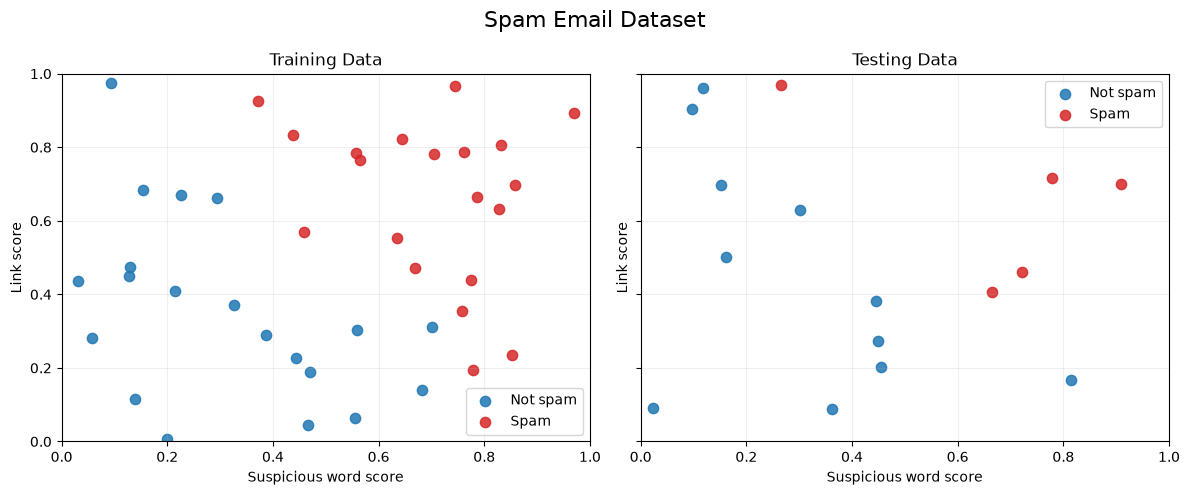

In [27]:
def plot_email_data(ax, X: np.ndarray, y: np.ndarray, title: str) -> None:
    """Plot spam and non-spam emails on one set of axes."""
    for label, color, name in [
        (0, "tab:blue", "Not spam"),
        (1, "tab:red", "Spam"),
    ]:
        rows = y == label
        ax.scatter(
            X[rows, 0],
            X[rows, 1],
            color=color,
            s=55,
            alpha=0.85,
            label=name,
        )

    ax.set_title(title)
    ax.set_xlabel("Suspicious word score")
    ax.set_ylabel("Link score")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.2)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

plot_email_data(axes[0], X_train, y_train, "Training Data")
plot_email_data(axes[1], X_test, y_test, "Testing Data")

fig.suptitle("Spam Email Dataset", fontsize=16)
fig.tight_layout()
plt.show()

[Suspicious word score], [Link inside email score]
[[0.77395605 0.43887844]]


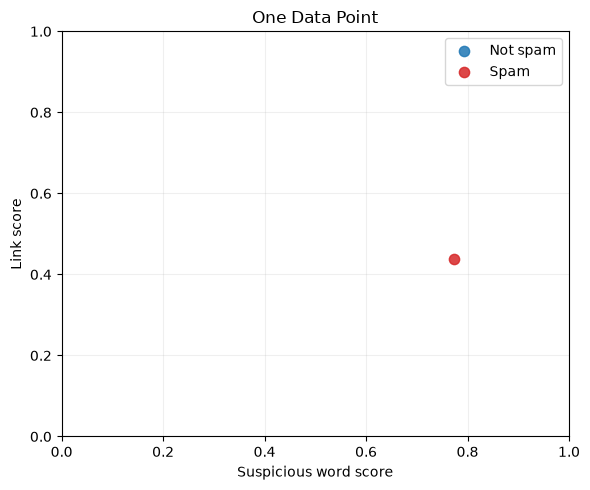

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))

print("[Suspicious word score], [Link inside email score]")
print(f"{X_train[0:1]}")

plot_email_data(
    ax,
    X_train[0:1],
    y_train[0:1],
    "One Data Point",
)

fig.tight_layout()
plt.show()

## Sigmoid function

![Sigmoid function](img/sigmoid.png)

In [29]:
def sigmoid(x: float) -> float:
    """Convert a real-valued input into a probability from 0 to 1."""
    return float(1 / (1 + np.exp(-x)))

## Cost function

![Cost function](img/cost-function.png)

In [ ]:
def compute_cost_logistic(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    b: float,
) -> float:
    """Compute the average logistic regression cost."""
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        prediction = sigmoid(np.dot(X[i], w) + b)
        cost += (
            -y[i] * np.log(prediction)
            - (1 - y[i]) * np.log(1 - prediction)
        )

    return float(cost / m)

In [31]:
def compute_gradient_logistic(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    b: float,
) -> tuple[float, np.ndarray]:
    """Compute the gradients for logistic regression."""
    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        prediction = sigmoid(np.dot(X[i], w) + b)
        error = prediction - y[i]
        dj_dw += error * X[i]
        dj_db += error

    return float(dj_db / m), dj_dw / m

## Gradient descent

![Gradient descent](img/gradient-descent.png)

In [32]:
def gradient_descent(
    X: np.ndarray,
    y: np.ndarray,
    w_in: np.ndarray,
    b_in: float,
    learning_rate: float,
    num_iters: int,
) -> tuple[np.ndarray, float, list[float]]:
    """Train a logistic regression model with batch gradient descent."""
    w = w_in.astype(float).copy()
    b = float(b_in)
    cost_history: list[float] = []

    for iteration in range(num_iters):
        dj_db, dj_dw = compute_gradient_logistic(X, y, w, b)

        w -= learning_rate * dj_dw
        b -= learning_rate * dj_db

        cost = compute_cost_logistic(X, y, w, b)
        cost_history.append(cost)

        if iteration % max(1, num_iters // 10) == 0:
            print(f"Iteration {iteration:4d}: cost = {cost:.6f}")

    return w, b, cost_history

In [33]:
initial_w = np.zeros(X_train.shape[1])
initial_b = 0.0

w_final, b_final, cost_history = gradient_descent(
    X_train,
    y_train,
    initial_w,
    initial_b,
    learning_rate=0.5,
    num_iters=1000,
)

print(f"Final weights: {w_final}")
print(f"Final bias: {b_final:.4f}")
print(f"Final cost: {cost_history[-1]:.6f}")

Iteration    0: cost = 0.685884
Iteration  100: cost = 0.412395
Iteration  200: cost = 0.315593
Iteration  300: cost = 0.266165
Iteration  400: cost = 0.235646
Iteration  500: cost = 0.214631
Iteration  600: cost = 0.199118
Iteration  700: cost = 0.187105
Iteration  800: cost = 0.177473
Iteration  900: cost = 0.169541
Final weights: [9.01099666 6.0291528 ]
Final bias: -7.5888
Final cost: 0.162934


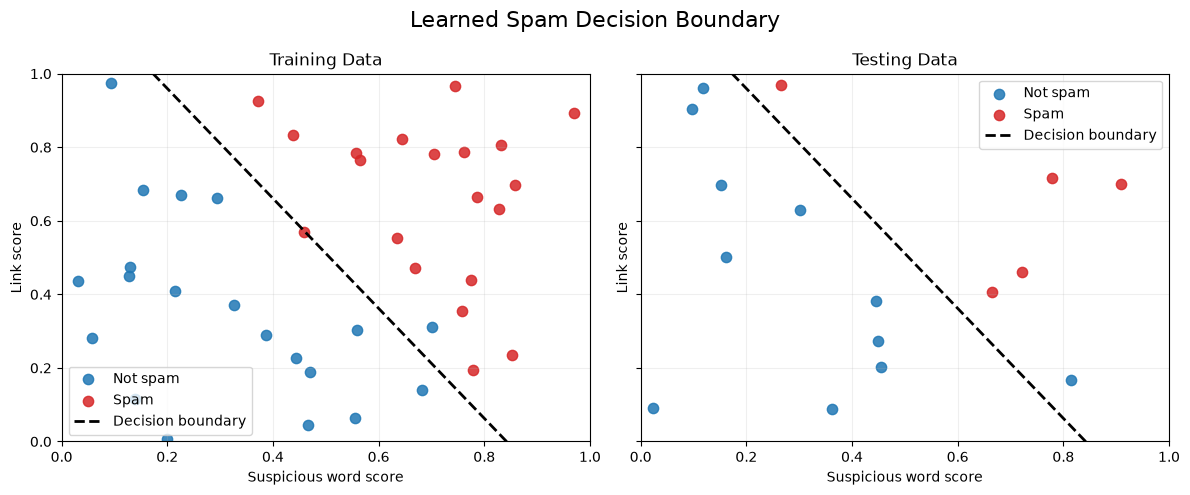

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

plot_email_data(axes[0], X_train, y_train, "Training Data")
plot_email_data(axes[1], X_test, y_test, "Testing Data")

# A probability of 0.5 occurs where w[0]x[0] + w[1]x[1] + b = 0.
x_boundary = np.linspace(0, 1, 100)
y_boundary = -(w_final[0] * x_boundary + b_final) / w_final[1]

for ax in axes:
    ax.plot(
        x_boundary,
        y_boundary,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Decision boundary",
    )
    ax.legend()

fig.suptitle("Learned Spam Decision Boundary", fontsize=16)
fig.tight_layout()
plt.show()

In [35]:
# see accuracy on test data set
test_scores = X_test @ w_final + b_final
test_probabilities = np.array([sigmoid(score) for score in test_scores])
test_predictions = (test_probabilities >= 0.5).astype(int)

correct = test_predictions == y_test
accuracy = np.mean(correct)

print(f"Accuracy: {accuracy:.1%}")

Accuracy: 93.8%


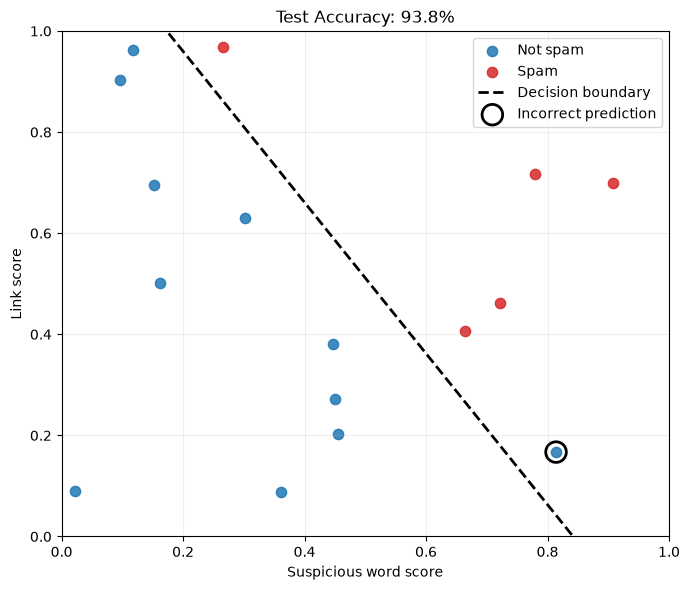

In [36]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_email_data(ax, X_test, y_test, f"Test Accuracy: {accuracy:.1%}")

ax.plot(
    x_boundary,
    y_boundary,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Decision boundary",
)

# Circle every email that the model classified incorrectly.
incorrect = ~correct
ax.scatter(
    X_test[incorrect, 0],
    X_test[incorrect, 1],
    facecolors="none",
    edgecolors="black",
    s=220,
    linewidth=2,
    label="Incorrect prediction",
)

ax.legend()
fig.tight_layout()
plt.show()